Install / import required packages

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn openpyxl


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Display settings (optional)
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')


Load the data

In [5]:
df = pd.read_csv("customer_segmentation.csv")
df.head()
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

Quick EDA (understand columns)

In [6]:
# summary stats
df.describe(include='all').T

# check missing values
df.isnull().sum()

# check duplicates
df.duplicated().sum()


0

Select features for clustering

In [13]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols


['ID',
 'Year_Birth',
 'Income',
 'Kidhome',
 'Teenhome',
 'Recency',
 'MntWines',
 'MntFruits',
 'MntMeatProducts',
 'MntFishProducts',
 'MntSweetProducts',
 'MntGoldProds',
 'NumDealsPurchases',
 'NumWebPurchases',
 'NumCatalogPurchases',
 'NumStorePurchases',
 'NumWebVisitsMonth',
 'AcceptedCmp3',
 'AcceptedCmp4',
 'AcceptedCmp5',
 'AcceptedCmp1',
 'AcceptedCmp2',
 'Complain',
 'Z_CostContact',
 'Z_Revenue',
 'Response',
 'Age']

Create an "Age" Column

In [19]:
df['Age'] = 2025 - df['Year_Birth']

features = df[[
    'Age', 'Income',
    'Kidhome', 'Teenhome',
    'Recency',

    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',

    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
    'NumStorePurchases', 'NumWebVisitsMonth'
]]

features.head()


,Age,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,68,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7
1,71,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5
2,60,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4
3,41,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6
4,44,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5


Visualize distributions & pairwise relationships

c:\Users\saipr\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


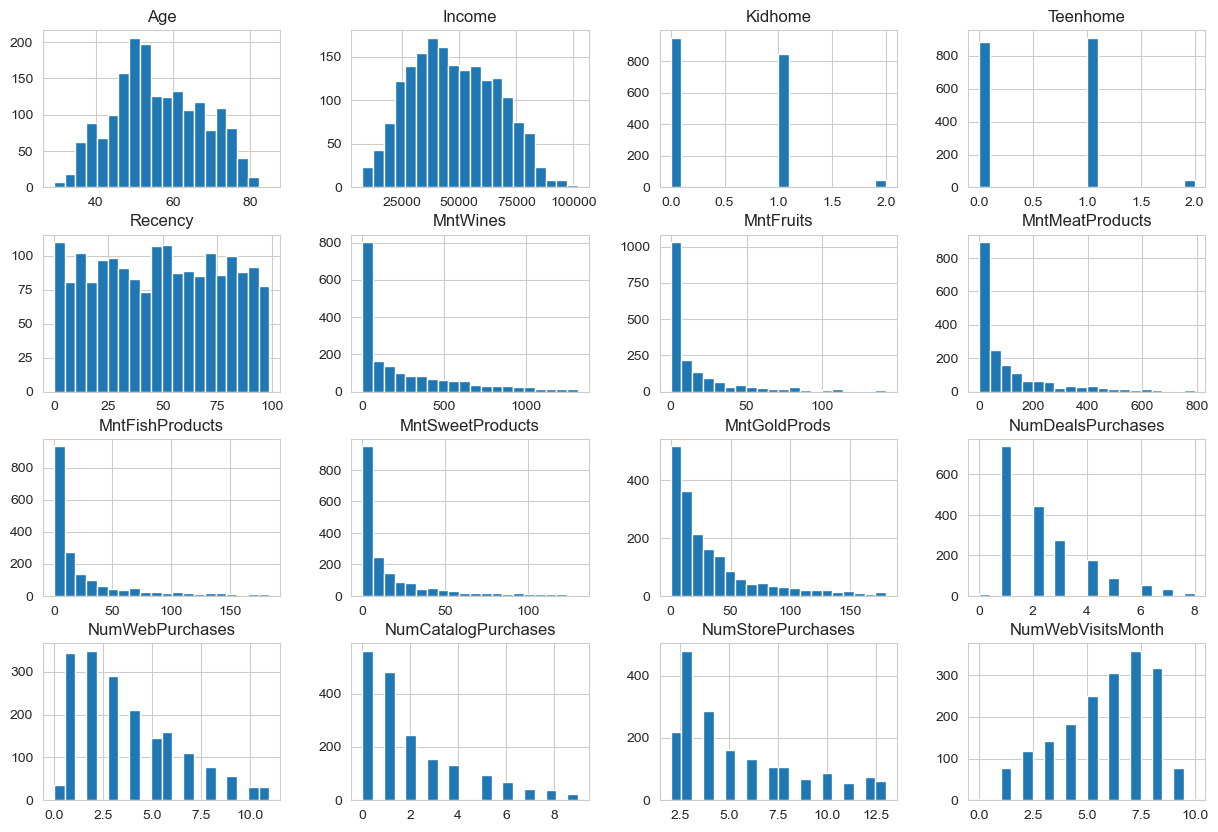

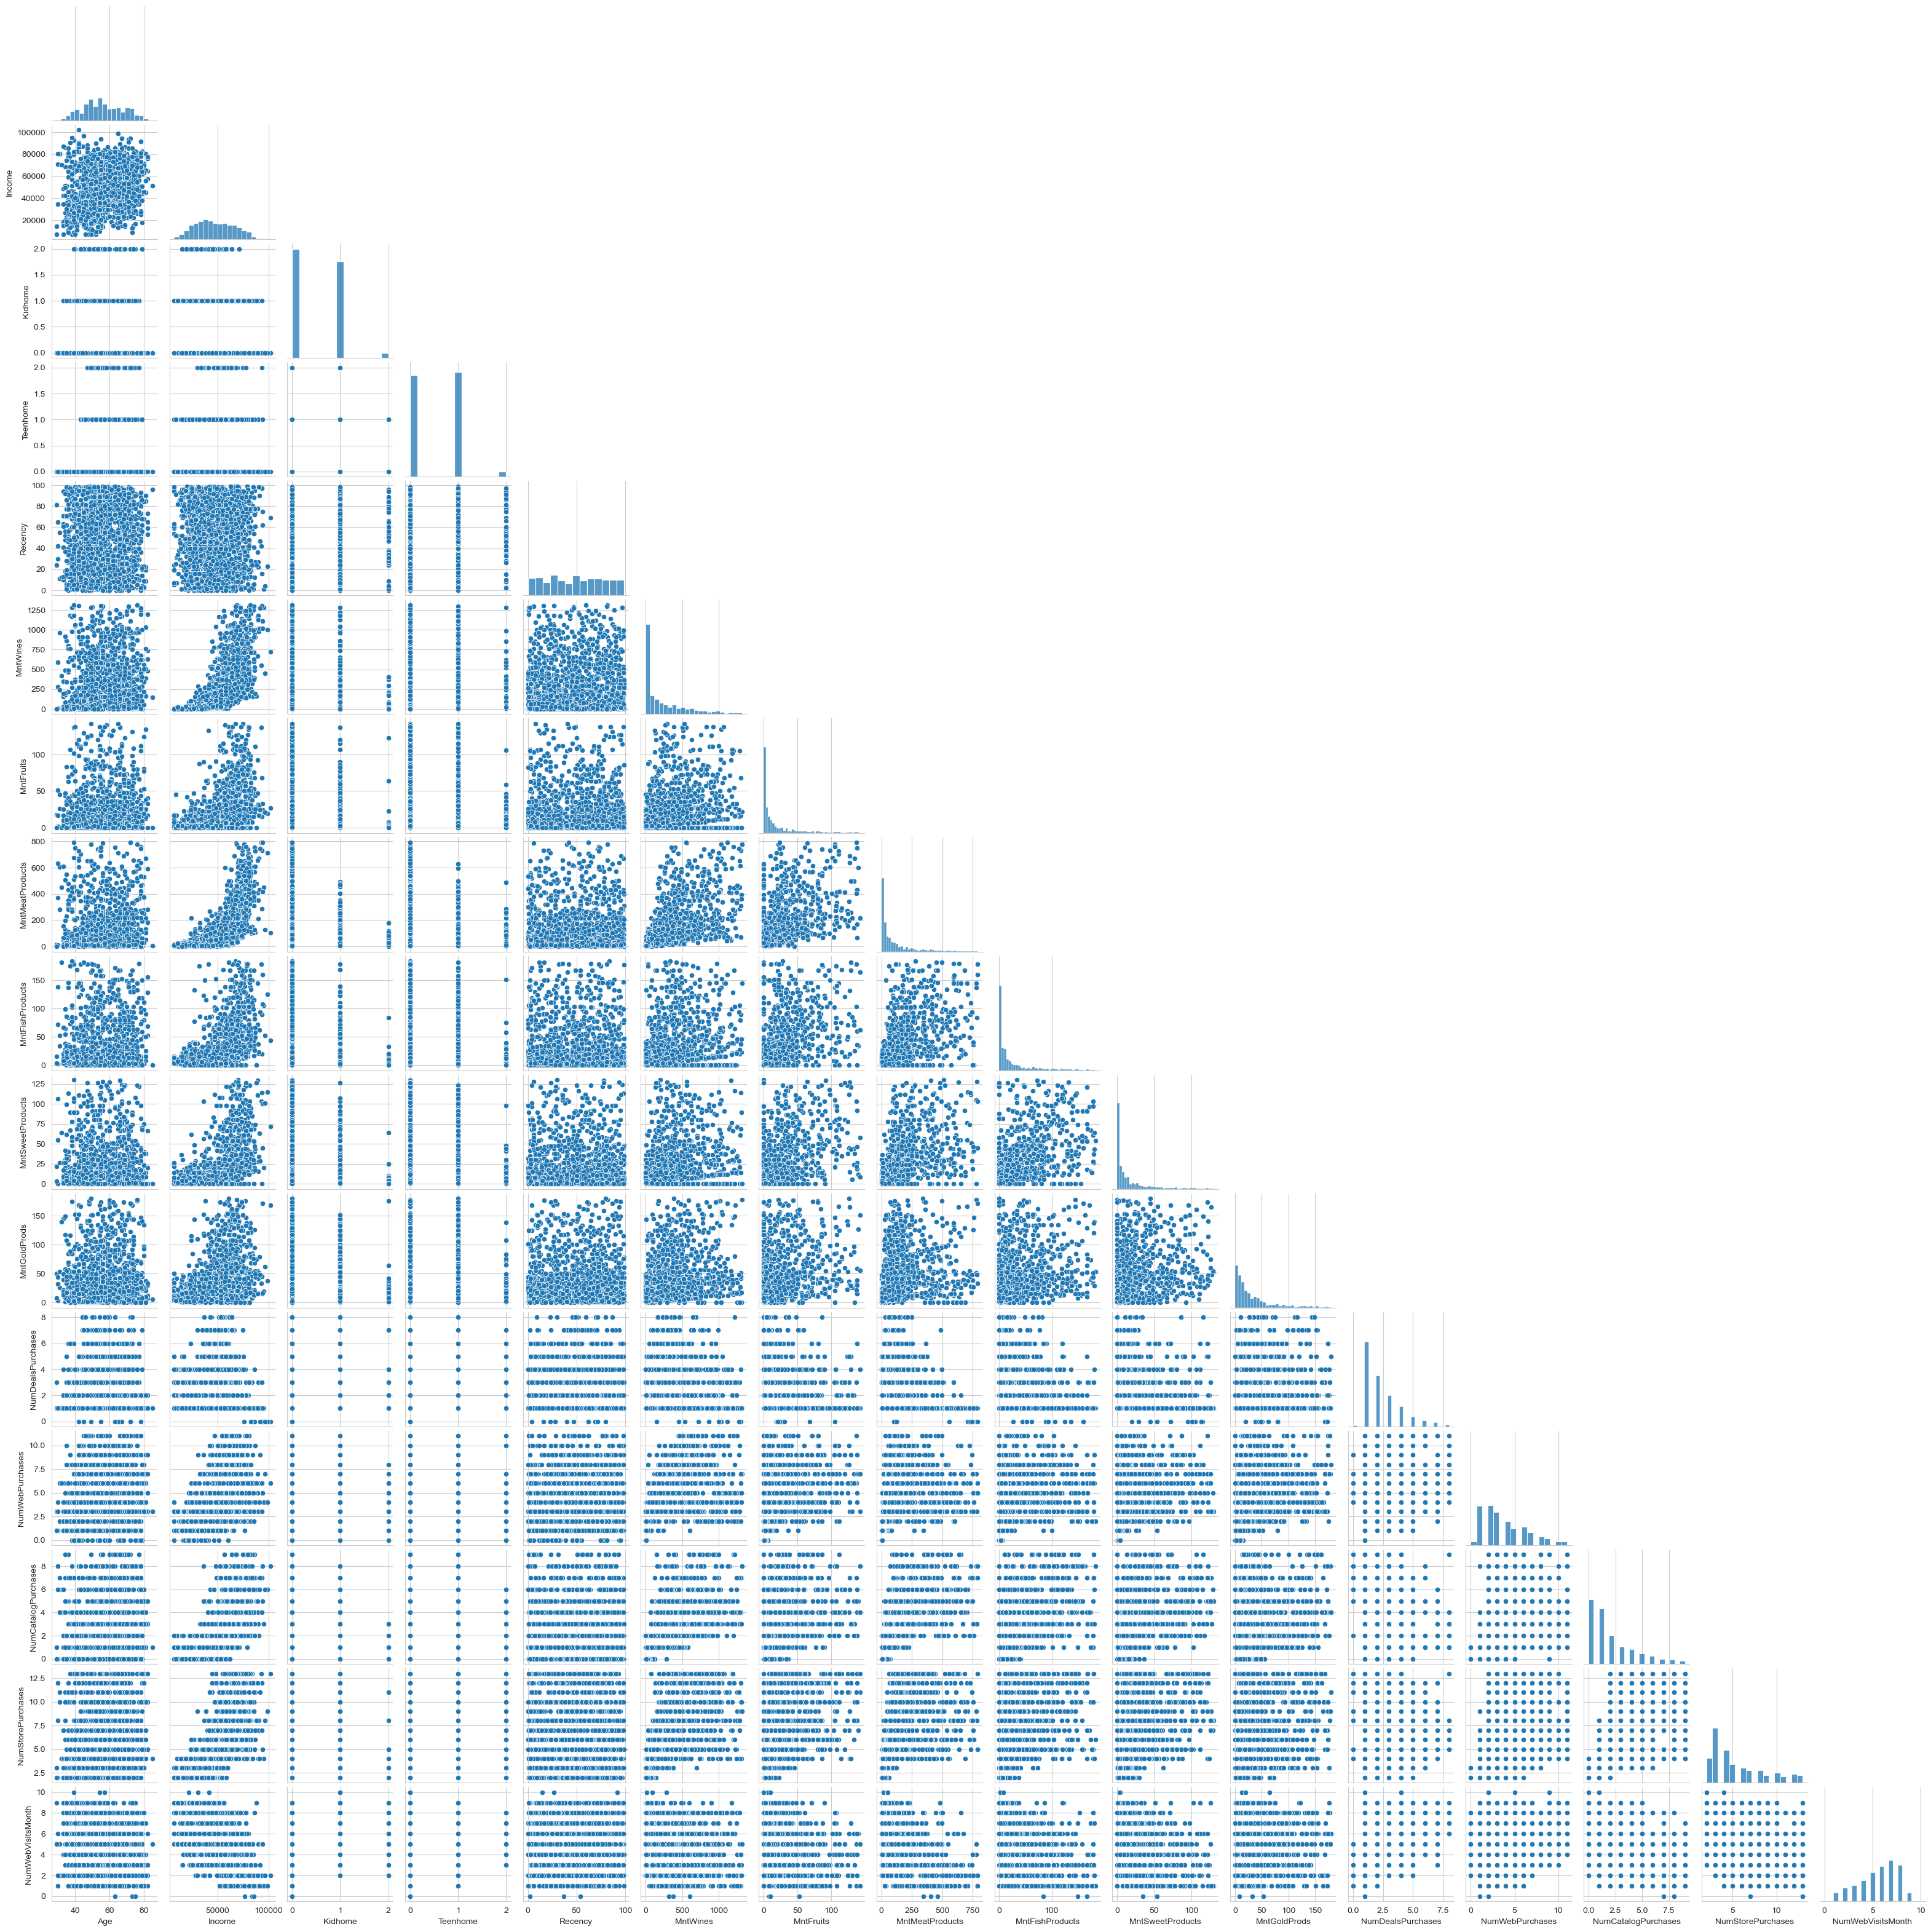

In [23]:
# histograms
features.hist(bins=20, figsize=(15,10));

# pairplot
sns.pairplot(features, corner=True, height=2.0);


Scaling the features

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)


Finding the optimal number of clusters

c:\Users\saipr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\saipr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\saipr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\saipr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Window

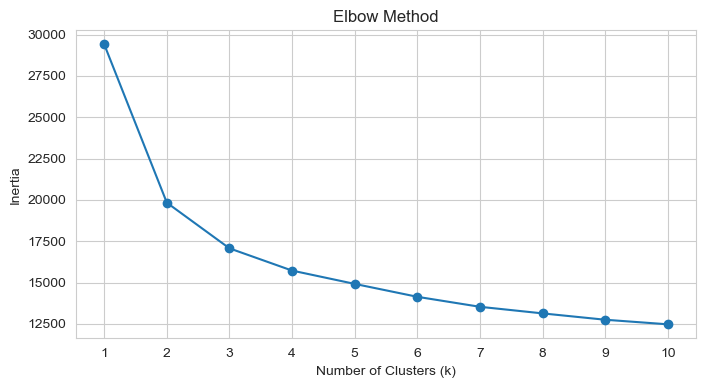

In [25]:
# Elbow Method (Inertia)
inertia = []
K = range(1, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(K)
plt.show()


In [26]:
# Silhouette Score (Cluster Quality)
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k = {k}, Silhouette Score = {score:.4f}")


c:\Users\saipr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


k = 2, Silhouette Score = 0.3301


c:\Users\saipr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


k = 3, Silhouette Score = 0.2488


c:\Users\saipr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


...

k = 5, Silhouette Score = 0.1650


c:\Users\saipr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


k = 6, Silhouette Score = 0.1675


c:\Users\saipr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


k = 7, Silhouette Score = 0.1614


Apply Final K-Means Model

In [28]:
df = df.loc[features.index].copy()
df['Cluster'] = kmeans.fit_predict(X_scaled)
df.head()


c:\Users\saipr\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Cluster
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,71,4
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,60,3
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,41,1
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,44,0
5,7446,1967,Master,Together,62513.0,0,1,09-09-2013,16,520,42,98,0,42,14,2,6,4,10,6,0,0,0,0,0,0,3,11,0,58,2


Create PCA Columns

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_vals = pca.fit_transform(X_scaled)

df['PC1'] = pca_vals[:, 0]
df['PC2'] = pca_vals[:, 1]

df[['PC1','PC2','Cluster']].head()


,PC1,PC2,Cluster
1,-1.954073,0.419307,4
2,2.957823,-0.838788,3
3,-2.404996,-1.267301,1
4,0.573549,-0.216437,0
5,1.902900,0.843033,2


Plot PCA Scatter (Very important visual)

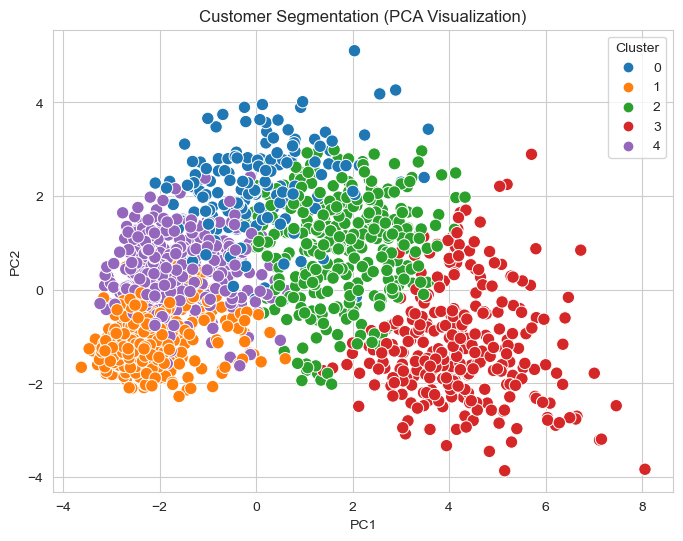

In [30]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=df,
    palette='tab10',
    s=80
)
plt.title("Customer Segmentation (PCA Visualization)")
plt.show()


Cluster Heatmap (Center Values)

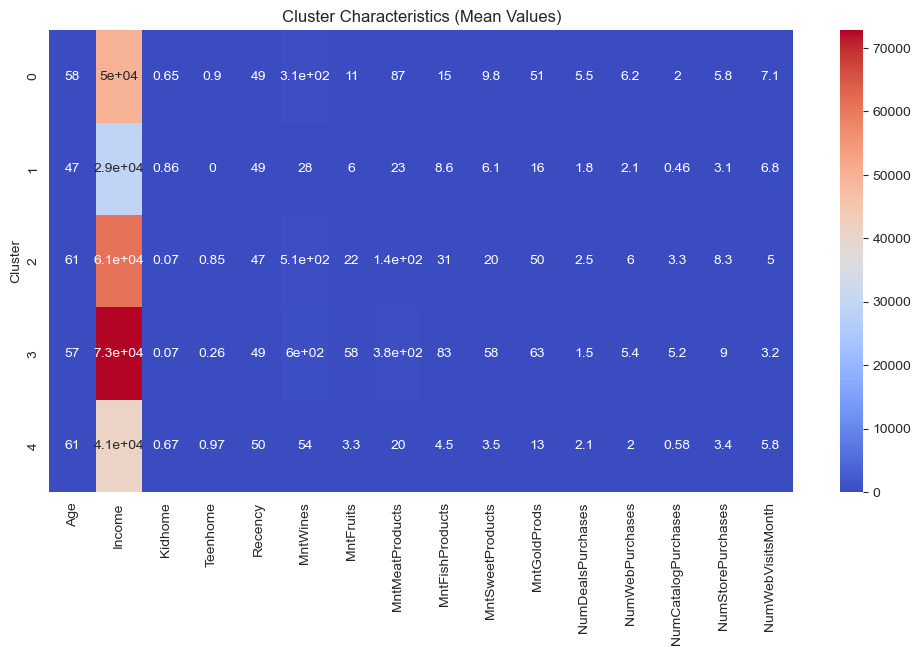

In [31]:
cluster_summary = df.groupby('Cluster')[features.columns].mean().round(2)

plt.figure(figsize=(12,6))
sns.heatmap(cluster_summary, annot=True, cmap='coolwarm')
plt.title("Cluster Characteristics (Mean Values)")
plt.show()


Label cluster groups

In [32]:
cluster_labels = {
    0: "High Spenders",
    1: "Low Engagement Users",
    2: "Top Value Customers",
    3: "Regular Multi-Channel Buyers",
    4: "Budget-Conscious Customers"
}

df["Segment"] = df["Cluster"].map(cluster_labels)
df[["Cluster", "Segment"]].head()


,Cluster,Segment
1,4,Budget-Conscious Customers
2,3,Regular Multi-Channel Buyers
3,1,Low Engagement Users
4,0,High Spenders
5,2,Top Value Customers


In [ ]:
df['Segment'].value_counts() #count of each segment


Segment
Low Engagement Users            527
Budget-Conscious Customers      458
Top Value Customers             348
Regular Multi-Channel Buyers    314
High Spenders                   191
Name: count, dtype: int64

Summary statistics per segment

In [34]:
segment_summary = df.groupby('Segment')[features.columns].mean().round(2)
segment_summary


,Age,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
Segment,,,,,,,,,,,,,,,,
Budget-Conscious Customers,61.35,40743.84,0.67,0.97,49.88,53.76,3.29,19.83,4.49,3.53,12.59,2.09,1.99,0.58,3.41,5.77
High Spenders,57.83,49914.24,0.65,0.90,49.48,314.01,10.59,87.27,15.01,9.76,51.13,5.53,6.17,2.02,5.84,7.13
Low Engagement Users,46.64,29056.51,0.86,0.00,48.90,27.73,5.99,23.05,8.61,6.06,15.54,1.77,2.13,0.46,3.07,6.85
Regular Multi-Channel Buyers,56.88,72784.20,0.07,0.26,49.00,595.07,57.58,382.65,83.16,57.81,63.41,1.49,5.40,5.15,9.01,3.17
Top Value Customers,60.99,60949.07,0.07,0.85,47.32,513.14,21.80,141.27,30.83,20.15,49.78,2.48,5.96,3.32,8.34,4.96
